# 02 Preprocessing

Run the reusable preprocessing pipeline and inspect the cleaned outputs.

In [17]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import json
import pandas as pd

from src.preprocess import run_preprocessing
from src.data_utils import build_paths

metadata = run_preprocessing()
metadata

{'random_seed': 42,
 'raw_rows': 3549,
 'rows_after_filtering': 2786,
 'excluded_rows': 763,
 'duplicate_rows_dropped': 193,
 'invalid_label_rows': 63,
 'missing_text_rows': 34,
 'split_sizes': {'train': 1950, 'val': 418, 'test': 418},
 'label_distribution': {'positive': 1113, 'negative': 1091, 'neutral': 582},
 'emoji_rows': 747,
 'emoji_token_count': 1943,
 'raw_files': ['Copy of Facebook_Comment_Annotation - Perpetual.csv',
  'Facebook_Comment_Annotation - Alfred.csv',
  'Facebook_Comment_Annotation - Fitina.csv',
  'Facebook_Comment_Annotation - Perpetual.csv',
  'Facebook_Comment_Annotation - Rahema.csv',
  'Facebook_Comment_Annotation - Thando.csv',
  'Facebook_Comment_Annotation - Viwongo.csv',
  'Facebook_comments - Lutha.csv',
  'Facebook_comments - phiti.csv',
  'Facebook_comments - rahe.csv',
  'Facebook_comments - viwo.csv',
  'facebook-comment-annotation2 - Exposition.csv',
  'facebook-comment-annotation2 - Fitina.csv',
  'facebook-comment-annotation2 - Luthando.csv',
  'f

In [18]:
paths = build_paths()
cleaned = pd.read_csv(paths.interim_dir / 'cleaned_comments.csv')
cleaned[['text', 'cleaned_text', 'label']].head(20)

,text,cleaned_text,label
0,Zamphamvu kwambiri,zamphamvu kwambiri,positive
1,"Learning by doing approach, that's wonderful 🔥 🔥.","learning by doing approach , that ' s wonderfu...",positive
2,Code kampani ya maheu ija ili kut inu a mcp..,code kampani ya maheu ija ili kut inu a mcp..,neutral
3,Something that the presidents failed to do!🔥,something that the presidents failed to do!🔥 e...,positive
4,Kma andale akanakhar amaganizaso ngat big man ...,kma andale akanakhar amaganizaso ngat big man ...,neutral
5,"Zikatero boma la DPP limukorekole, ma mafia am...","zikatero boma la dpp limukorekole , ma mafia a...",negative
6,Uyu mpaseni u president 🥳,uyu mpaseni u president 🥳 emoji_partying_face,positive
7,Pomwe ma politicians amakhala busy kudya mison...,pomwe ma politicians amakhala busy kudya mison...,positive
8,"Dear God, as far as Malawi is concerned. A Nap...","dear god , as far as malawi is concerned. a na...",positive
9,"Zomwe dzombe sangapange,boma la Malawi silinga...","zomwe dzombe sangapange , boma la malawi silin...",positive


In [19]:
cleaned.head(10)

,id,text,topic_label,sentiment_label,confidence,include,notes,source_file,sentiment_label_normalized,include_normalized,...,token_count_whitespace,is_short_comment,is_duplicate_text,exclude_reason,label,emoji_aliases,emoji_count,cleaned_text,tokens,token_count_cleaned
0,332.0,Zamphamvu kwambiri,Economy,positive,Medium,Yes,praise,Copy of Facebook_Comment_Annotation - Perpetua...,positive,yes,...,2,False,False,NaN,positive,NaN,0,zamphamvu kwambiri,"['zamphamvu', 'kwambiri']",2
1,334.0,"Learning by doing approach, that's wonderful 🔥 🔥.",Economy,positive,High,Yes,teaching method,Copy of Facebook_Comment_Annotation - Perpetua...,positive,yes,...,8,False,False,NaN,positive,emoji_fire emoji_fire,2,"learning by doing approach , that ' s wonderfu...","['learning', 'by', 'doing', 'approach', ',', '...",13
2,335.0,Code kampani ya maheu ija ili kut inu a mcp..,Economy,Neutral,medium,Yes,company,Copy of Facebook_Comment_Annotation - Perpetua...,neutral,yes,...,10,False,False,NaN,neutral,NaN,0,code kampani ya maheu ija ili kut inu a mcp..,"['code', 'kampani', 'ya', 'maheu', 'ija', 'ili...",10
3,336.0,Something that the presidents failed to do!🔥,Economy,positive,High,Yes,leadership comparison,Copy of Facebook_Comment_Annotation - Perpetua...,positive,yes,...,7,False,False,NaN,positive,emoji_fire,1,something that the presidents failed to do!🔥 e...,"['something', 'that', 'the', 'presidents', 'fa...",8
4,337.0,Kma andale akanakhar amaganizaso ngat big man ...,Economy,Neutral,Medium,Yes,governance comment,Copy of Facebook_Comment_Annotation - Perpetua...,neutral,yes,...,25,False,False,NaN,neutral,emoji_folded_hands,1,kma andale akanakhar amaganizaso ngat big man ...,"['kma', 'andale', 'akanakhar', 'amaganizaso', ...",27
5,339.0,"Zikatero boma la DPP limukorekole, ma mafia am...",Economy,negative,medium,Yes,criticism of government,Copy of Facebook_Comment_Annotation - Perpetua...,negative,yes,...,21,False,False,NaN,negative,NaN,0,"zikatero boma la dpp limukorekole , ma mafia a...","['zikatero', 'boma', 'la', 'dpp', 'limukorekol...",25
6,340.0,Uyu mpaseni u president 🥳,Economy,positive,High,Yes,praise,Copy of Facebook_Comment_Annotation - Perpetua...,positive,yes,...,5,False,False,NaN,positive,emoji_partying_face,1,uyu mpaseni u president 🥳 emoji_partying_face,"['uyu', 'mpaseni', 'u', 'president', '🥳', 'emo...",6
7,341.0,Pomwe ma politicians amakhala busy kudya mison...,Economy,positive,Medium,Yes,NaN,Copy of Facebook_Comment_Annotation - Perpetua...,positive,yes,...,21,False,False,NaN,positive,NaN,0,pomwe ma politicians amakhala busy kudya mison...,"['pomwe', 'ma', 'politicians', 'amakhala', 'bu...",21
8,342.0,"Dear God, as far as Malawi is concerned. A Nap...",Economy,positive,Medium,Yes,leadership,Copy of Facebook_Comment_Annotation - Perpetua...,positive,yes,...,12,False,False,NaN,positive,NaN,0,"dear god , as far as malawi is concerned. a na...","['dear', 'god', ',', 'as', 'far', 'as', 'malaw...",13
9,344.0,"Zomwe dzombe sangapange,boma la Malawi silinga...",Economy,positive,High,Yes,comparison praise,Copy of Facebook_Comment_Annotation - Perpetua...,positive,yes,...,38,False,False,NaN,positive,NaN,0,"zomwe dzombe sangapange , boma la malawi silin...","['zomwe', 'dzombe', 'sangapange', ',', 'boma',...",47


<Axes: xlabel='sentiment_label_normalized'>

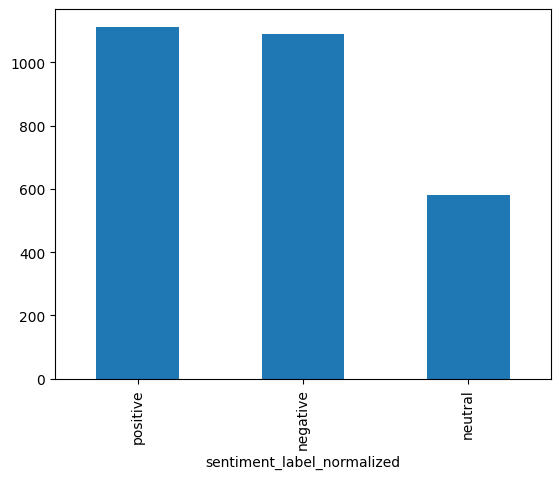

In [20]:
cleaned["sentiment_label_normalized"].value_counts().plot(kind='bar')

In [22]:
cleaned.sample(min(10, len(cleaned)), random_state=42)

,id,text,topic_label,sentiment_label,confidence,include,notes,source_file,sentiment_label_normalized,include_normalized,...,token_count_whitespace,is_short_comment,is_duplicate_text,exclude_reason,label,emoji_aliases,emoji_count,cleaned_text,tokens,token_count_cleaned
2078,285.0,Koma kod nkuluyi mesa nae zitamuthina amagwili...,economy,negative,high,yes,NaN,sentiment2 spreadsheet - fitina.csv,negative,yes,...,33,False,False,NaN,negative,emoji_winking_face_with_tongue emoji_grinning_...,2,koma kod nkuluyi mesa nae zitamuthina amagwili...,"['koma', 'kod', 'nkuluyi', 'mesa', 'nae', 'zit...",35
2770,NaN,Khan yabwino,economy,positive,high,yes,NaN,sentiment2 spreadsheet - viwongo.csv,positive,yes,...,2,False,False,NaN,positive,NaN,0,khan yabwino,"['khan', 'yabwino']",2
1465,23.0,"Ingobwelesani fuel wokwanila, otherwise deploy...",economy,negative,high,yes,NaN,sentiment spreadsheet - rahema.csv,negative,yes,...,18,False,False,NaN,negative,emoji_face_with_tears_of_joy emoji_face_with_t...,3,"ingobwelesani fuel wokwanila , otherwise deplo...","['ingobwelesani', 'fuel', 'wokwanila', ',', 'o...",22
2089,296.0,Naye Chakwela sangataketake apilizi chonde,economy,negative,medium,yes,NaN,sentiment2 spreadsheet - fitina.csv,negative,yes,...,5,False,False,NaN,negative,NaN,0,naye chakwela sangataketake apilizi chonde,"['naye', 'chakwela', 'sangataketake', 'apilizi...",5
2118,331.0,Ntchito mukuigwilatu,economy,positive,high,yes,NaN,sentiment2 spreadsheet - fitina.csv,positive,yes,...,2,False,False,NaN,positive,NaN,0,ntchito mukuigwilatu,"['ntchito', 'mukuigwilatu']",2
141,435.0,Uyu nde alemba hito ma galajuweti 🙌🫡🫡 but hims...,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Fitina.csv,positive,yes,...,13,False,False,NaN,positive,emoji_raising_hands emoji_saluting_face emoji_...,5,uyu nde alemba hito ma galajuweti 🙌🫡🫡 but hims...,"['uyu', 'nde', 'alemba', 'hito', 'ma', 'galaju...",18
2367,103.0,We give nt cz we hve a lot bt we know hw it f...,economy,positive,medium,yes,NaN,sentiment2 spreadsheet - rahema.csv,positive,yes,...,22,False,False,NaN,positive,NaN,0,we give nt cz we hve a lot bt we know hw it fe...,"['we', 'give', 'nt', 'cz', 'we', 'hve', 'a', '...",22
324,3.0,"Napoleon Grasshoppers, thinks like AI",Economy,Neutral,Medium,Yes,Doesnt make sense,Facebook_Comment_Annotation - Viwongo.csv,neutral,yes,...,5,False,False,NaN,neutral,NaN,0,"napoleon grasshoppers , thinks like ai","['napoleon', 'grasshoppers', ',', 'thinks', 'l...",6
1580,159.0,Paja wa police waku Malawi alibe nthito mkona ...,economy,neutral,medium,yes,NaN,sentiment spreadsheet - rahema.csv,neutral,yes,...,10,False,False,NaN,neutral,NaN,0,paja wa police waku malawi alibe nthito mkona ...,"['paja', 'wa', 'police', 'waku', 'malawi', 'al...",10
1089,904.0,Make fuel available basi,economy,neutral,high,yes,NaN,sentiment spreadsheet - alfred.csv,neutral,yes,...,4,False,False,NaN,neutral,NaN,0,make fuel available basi,"['make', 'fuel', 'available', 'basi']",4


In [23]:
train = pd.read_csv(paths.processed_dir / 'train.csv')
val = pd.read_csv(paths.processed_dir / 'val.csv')
test = pd.read_csv(paths.processed_dir / 'test.csv')
len(train), len(val), len(test)

(1950, 418, 418)

<Axes: xlabel='sentiment_label_normalized'>

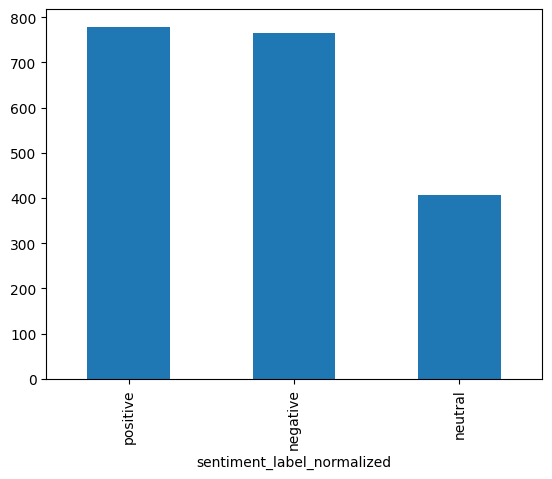

In [24]:
train['sentiment_label_normalized'].value_counts().plot(kind='bar')

<Axes: xlabel='sentiment_label_normalized'>

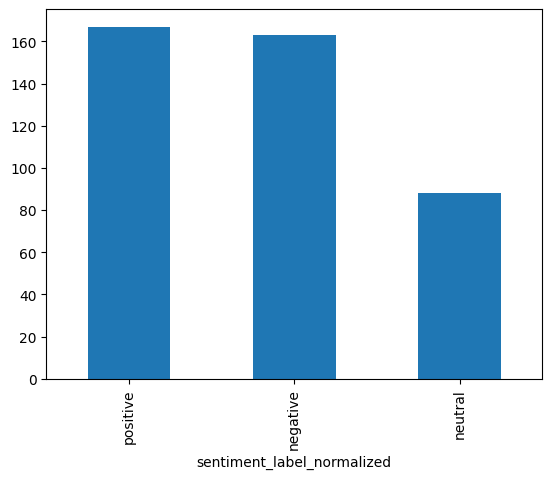

In [25]:
val['sentiment_label_normalized'].value_counts().plot(kind='bar')